<div><center><img src="https://ml.ucv.ai/logo.png" width="150"/> </center></div>

# Asignación #2

## Mineria de Datos [UCV]


* Alumno: Carlos Cao
* Cédula: 28655925
----


# EDA - Dataset de Carros

El conjunto de datos `car-dataset` contiene registro detallado sobre modelos de carros comercializados a lo largo de varios años, donde combina variables categóricas (como Marca, Modelo y Tipo de transmisión) con numéricas (como Caballos de fuerza, Cilindros y Rendimiento de combustible/MPG).

El objetivo de este notebook es realizar un análisis exploratorio de datos aplicado al conjunto de datos `car-dataset`. Donde buscaremos comprender a profundidad la estructura de la información, descubrir patrones iniciales y evaluar la calidad de los datos antes de cualquier etapa de modelado.

## Configuración Inicial y Carga de Datos

En esta sección importamos las librerías necesaria para la manipulación de datos y la generación de gráficos. Además, configuramos el estilo visual por defecto y el dataset se encuentra cargado en mi repositorio de github donde cargaremos los datos.

In [63]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import warnings
warnings.filterwarnings('ignore')

URL_DATOS = "https://raw.githubusercontent.com/CaoCarlos55/DM_II_2025/refs/heads/main/Asignaci%C3%B3n_2/data.csv"

# Cargamos el dataset
df = pd.read_csv(URL_DATOS)

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

display(df.head())

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## Descripción del Dataset

Vamos a analizar la dimensión del conjunto de datos, revisando el número total de filas y columnas. Además, verificaremos los tipos de datos asignados a cada variable para confirmar cuáles son numéricas y cuáles categóricas.

In [64]:
print(f"Número total de filas: {df.shape[0]}")
print(f"Número total de columnas: {df.shape[1]}\n")
print("Tipos de datos asignados a cada columna:")
print(df.dtypes)

Número total de filas: 11914
Número total de columnas: 16

Tipos de datos asignados a cada columna:
Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object


Este conjunto de datos posee un tamaño considerable de información con 11,914 observaciones y 16 caracteristicas. Al observar los tipos de datos, confirmamos que el dataset es bastante variado, porque contiene variables numéricas (`int64`, `float64`) ideales para análisis estadísticos de rendimiento y precio, así como variables categóricas (`object`) que nos servirán para agrupar y separar los datos por marca, modelo o tipo de transmisión.

## Estadísticas Descriptivas

Continuando con el analisis nos enfocaremos en las variables numéricas del dataset. Aca, contruiremos una tabla resumen que contenga la media, la mediana, la desviación estándar, el valor mínimo y el valor máximo para cada uno de estos atributos, lo que nos permitirá entender como se comporta la distribución de los datos.

In [65]:
# Filtramos el dataset para quedarnos solo las variables numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

estadisticas = pd.DataFrame({
    'Media': df_numerico.mean(),
    'Mediana': df_numerico.median(),
    'Desv. Estándar': df_numerico.std(),
    'Mínimo': df_numerico.min(),
    'Máximo': df_numerico.max()
})

display(estadisticas)

,Media,Mediana,Desv. Estándar,Mínimo,Máximo
Year,2010.384338,2015.0,7.579740,1990.0,2017.0
Engine HP,249.386070,227.0,109.191870,55.0,1001.0
Engine Cylinders,5.628829,6.0,1.780559,0.0,16.0
Number of Doors,3.436093,4.0,0.881315,2.0,4.0
highway MPG,26.637485,26.0,8.863001,12.0,354.0
city mpg,19.733255,18.0,8.987798,7.0,137.0
Popularity,1554.911197,1385.0,1441.855347,2.0,5657.0
MSRP,40594.737032,29995.0,60109.103604,2000.0,2065902.0



Podemos encontrar hallazgos interesantes sobre la distribución de los datos, el primero es sobre la variable objetivo `MSRP` que nos indica el precio de venta recomendado por el fabricante, en esta existe una diferencia notable entre su mediana y su valor máximo, al igual que la desviación estándar sumamente alta. Esto mismo ocurre con los caballos de fuerza `Engine HP`. Estas grandes diferencias numéricas nos alertan sobre la presencia de vehículos ultra lujosos que actuan como valores anomalos, arrastrando la media hacia arriba.

Tambien si nos enfocamos en el año de los carros, podemos notar que la mediana es superior a media, esto nos dice que la mayoría de los carros en el dataset son carros modernos pero existen carros viejos que tiran la media para abajo.

Además, con respecto a las variables `highway MPG` y `city mpg` que nos indica el consumo de combustible por milla en la autopista y en la ciudad, en esta la mayoría rinde alrededor de 26 MPG en autopista tomando la media y la mediana, pero existe un valor maximo de 354 MPG, cosa que no es posible en los carros tradicionales que utilizan gasolina. Esto nos quiere decir, que existen carros electricos en el dataset, las cuales utilizan un medida de rendimiento diferente que es el `MPGe`, generando valores atipicos altisimos o que hubo un error de tipeado en la observación. Con los cilindros `Engine Cylinders` podemos observar un valor inusual, en este caso es que el minimo es 0, estos solo es posible con carros electricos debido a que no poseen cilindros tradicionales.

## Valores Faltantes

Ahora verificaremos la integridad del conjunto de datos identificando la cantidad exacta de valores nulos presentes en cada columna.

In [66]:
total_filas = len(df)

# Calculamos la cantidad de nulos y su respectivo porcentaje
nulos_por_columna = df.isnull().sum()
porcentaje_nulos = (nulos_por_columna / total_filas) * 100

tabla_nulos = pd.DataFrame({
    'Total Observaciones': total_filas,
    'Cantidad de Nulos': nulos_por_columna,
    'Porcentaje (%)': porcentaje_nulos
})

# Ordenamos de mayor a menor
tabla_nulos_filtrada = tabla_nulos.sort_values(by='Cantidad de Nulos', ascending=False)

print("Columnas con valores faltantes:")
display(tabla_nulos_filtrada.round(2))

Columnas con valores faltantes:


,Total Observaciones,Cantidad de Nulos,Porcentaje (%)
Market Category,11914,3742,31.41
Engine HP,11914,69,0.58
Engine Cylinders,11914,30,0.25
Number of Doors,11914,6,0.05
Engine Fuel Type,11914,3,0.03
Model,11914,0,0.00
Year,11914,0,0.00
Make,11914,0,0.00
Driven_Wheels,11914,0,0.00
Transmission Type,11914,0,0.00


Podemos observar que la columna con mayor presencia de valores nulo es `Market Category`. De un total de 11,914 observaciones, faltan 3,742 lo que representa un 31.41% de pérdida de información. Esto nos indica que casi un tercio de los carros no fueron clasificados en un mercado específico durante la recolección de datos, generando un problema de integridad.

Otras variables con valores nulos, como `Engine HP`, `Engine Cylinders`, `Number of Doors` y `Engine Fuel Type` presentan una pérdida de información menor al 1%. Estos valores vacíos no comprometen la integridad del dataset y pueden ser manejados fácilmente con un preprocesamiento, ya sea imputando la mediana o eliminando esas escasas filas.

El resto de las variables del dataset no poseen ningún valor faltante, esto es una muy bueno para realizar un análisis completo, ya que nos evita imputar algun valor que podría generar algun sesgo en los resultados.

## Análisis de Distribución con Histogramas

Para entender cómo se distribuyen los datos, vamos a generar histogramas para tres variables, estas seran el precio `MSRP`, los caballos de fuerza `Engine HP` y el rendimiento de combustible en ciudad `city mpg`.

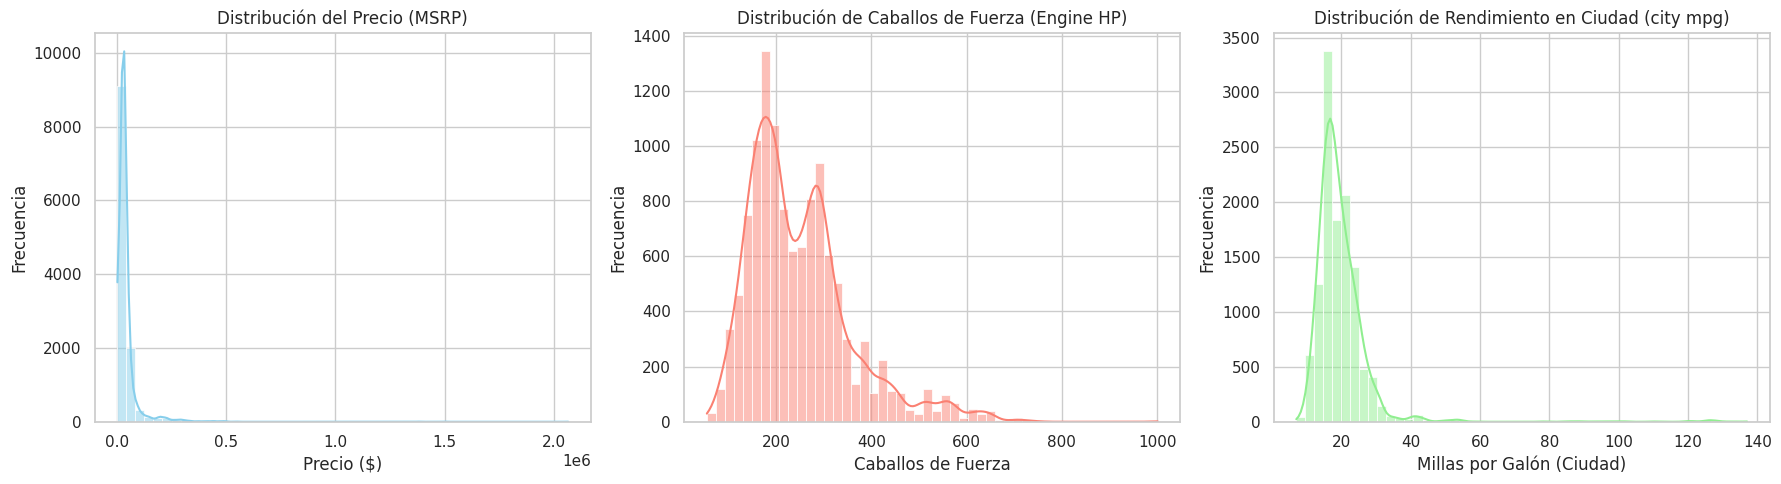

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma 1
sns.histplot(df['MSRP'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución del Precio (MSRP)')
axes[0].set_xlabel('Precio ($)')
axes[0].set_ylabel('Frecuencia')

# Histograma 2
sns.histplot(df['Engine HP'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de Caballos de Fuerza (Engine HP)')
axes[1].set_xlabel('Caballos de Fuerza')
axes[1].set_ylabel('Frecuencia')

# Histograma 3
sns.histplot(df['city mpg'], bins=50, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribución de Rendimiento en Ciudad (city mpg)')
axes[2].set_xlabel('Millas por Galón (Ciudad)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


Como podemos observar las tres variables presentan una fuerte asimetría hacia la derecha debido a la presencia de valores atípicos extremos debido a algunas observaciones donde poseen caracteristicas como 2 millones en precio, motores de 1000 HP y autos eléctricos de 137 MPG.

En la distribución de los caballos de fuerzas se tiene dos puntos donde hay una gran concentracion de valores. El primero esta alrededor de 200HP, probablemente porque correspondan a carros compacto y estandar, y un segundo punto cercano a los 300HP que pueden tratarse de carros deportivos de gama entrada.

Por otro lado, al revisar el consumo de combustible en la ciudad se contempla una distrubución un poco mas normal donde los valores se agrupan estrechamente alrededor de las 15 a 20 millas, cayendo drásticamente después de las 30 MPG.

En el caso del precio, el histograma muestra una asimetría positiva tan extrema que se ve una sola barra aplastada a la izquierda. Esto se debe a la presencia de carros ultra lujosos con valores muy superiores.

Para poder analizar la verdadera forma de la distribución y entender el comportamiento del mercado, aplicaremos un "zoom" visual, filtrando únicamente los vehículos con un precio menor a \$150,000.

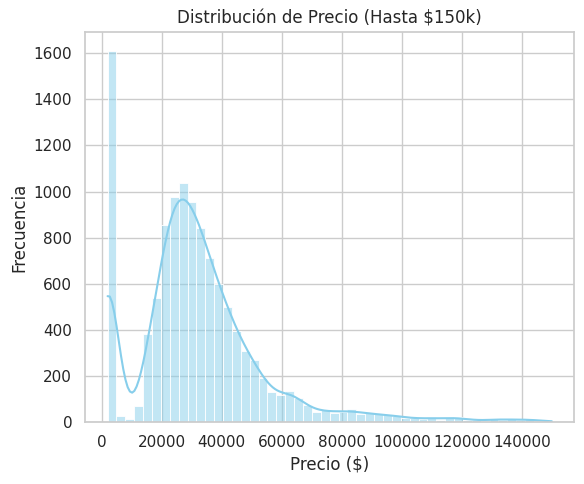

In [68]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))

sns.histplot(df[df['MSRP'] < 150000]['MSRP'], bins=50, kde=True, ax=axes, color='skyblue')
axes.set_title('Distribución de Precio (Hasta $150k)')
axes.set_xlabel('Precio ($)')
axes.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Con este ajuste visual, ahora podemos notar claramente que la distribución del precio de los carros se concentra en el rango de los \$20,000 a \$40,000, y la frecuencia disminuye de manera drástica y progresiva a medida que el precio entra en la categoría de carros de lujo. Adicionalmente, se destaca un pico inusual en el lado izquierdo, esto conformado por la gran cantidad de carros con un costo cercano a los \$2,000. Este comportamiento anómalo probablemente corresponde a un conjunto de carros antiguos, reflejando los precio que tenian en esa epoca.

## Box Plots para detectar valores anomalos

Para identificar formalmente la presencia de valores anomalos en nuestro conjunto de datos, utilizaremos diagramas de caja, esto nos permite observar la dispersión de los datos basándonos en cuartiles y detectar fácilmente aquellos registros que se escapan de los límites normales.

Para este análisis, seleccionamos dos variables clave que mostraron indicios de anomalías en las etapas previas, estas son el precio `MSRP` y los caballos de fuerzas `Engine HP`.

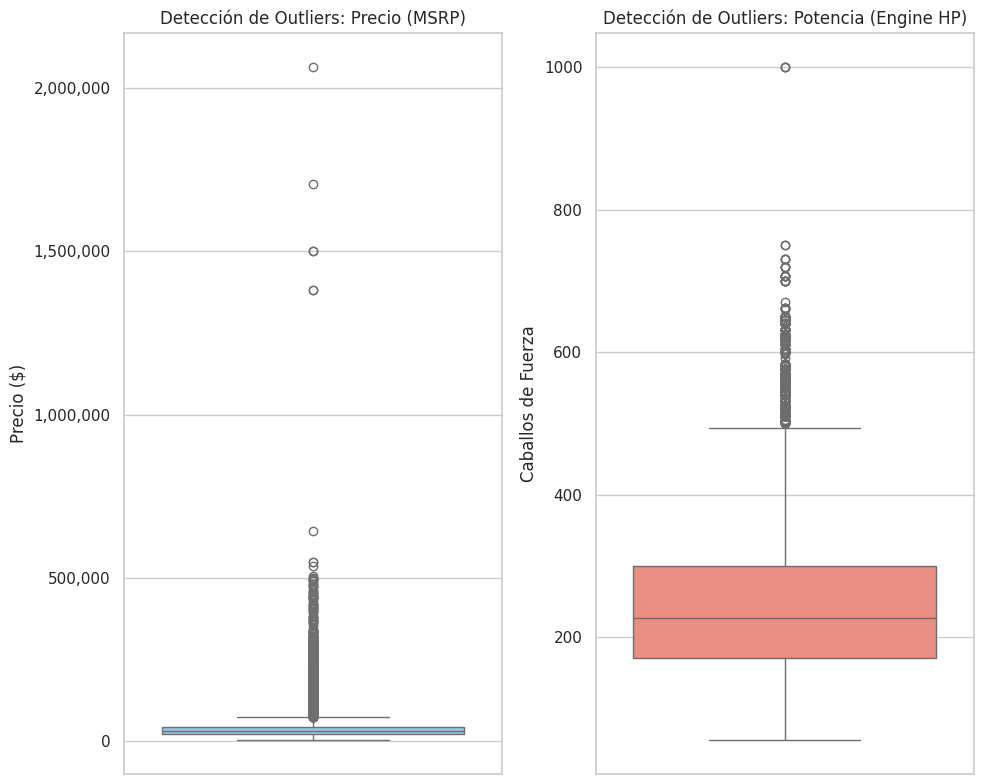

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

# Box plot 1
sns.boxplot(y=df['MSRP'], ax=axes[0], color='skyblue')
axes[0].set_title('Detección de Outliers: Precio (MSRP)')
axes[0].set_ylabel('Precio ($)')
axes[0].yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Box plot 2
sns.boxplot(y=df['Engine HP'], ax=axes[1], color='salmon')
axes[1].set_title('Detección de Outliers: Potencia (Engine HP)')
axes[1].set_ylabel('Caballos de Fuerza')

plt.tight_layout()
plt.show()

En ambos gráficos, por encima del bigote superior, se observa una densa nube de puntos individuales que se extienden hacia la parte alta del gráfico. Cada uno de estos puntos representa un valor anomalo.

En el caso del box plot del `MSRP` la caja principal se encuentra fuertemente comprimidad en la parte inferior, esto confirma que la gran mayoría de los carros se concentra por debajo de los \$80,000. La extensa estela de puntos que se dispara hacia arriba, superando incluso la barrera del millón de dólares, representa el segmento de carros ultra lujosos. En cuanto al gráfico de `Engine HP` la caja principal no se encuentra tan compactada pero tambien se encuentra en la mitad de la parte inferior. Esto quiere decir que la potencia estándar se agrupa por debajo de los 400 HP, mientras que los puntos que se elevan hasta alcanzar los 1000 HP corresponden a los carros de alto rendimiento y superdeportivos que se desvían de esta norma.

## Análisis de Correlación

Finalmente evaluaremos la relación entre las variables del dataset.

Para lograrlo, calcularemos la matriz de correlación y utilizaremos un mapa de calor para visualizarlo. Esto nos permitirá identificar qué características están fuertemente relacionadas. Luego, generaremos un gráfico de dispersión para el par de variables con la correlación más alta.

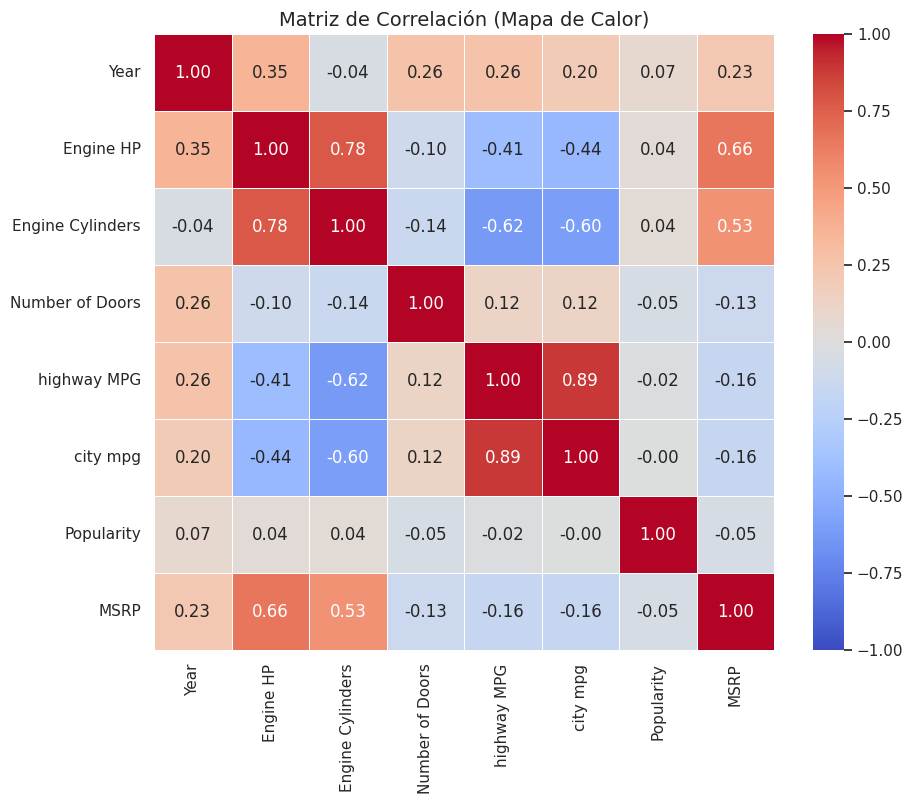

In [70]:
matriz_correlacion = df_numerico.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Matriz de Correlación (Mapa de Calor)', fontsize=14)
plt.show()

Con el mapa de calor podemos observar que hay coeficiente de 0.89, esta es la la relación más fuerte del conjunto de datos y se da entre las millas por combustible en la ciudad `city mpg` y las millas por combustible en la autopista `highway MPG`. Esto tiene todo mucho sentido, porque un vehículo diseñado para ser eficiente en entornos urbanos, es altamente probable que también sea eficiente en la autopista.

Adicional a esto, el mapa de calor también nos revela que la característica que más influye en el precio final del carro `MSRP` es su potencia o caballo de fuerzas `Engine HP`, con una correlación positiva del 0.66. Es decir, la potencia del motor es el mejor predictor del precio de un auto en este dataset.

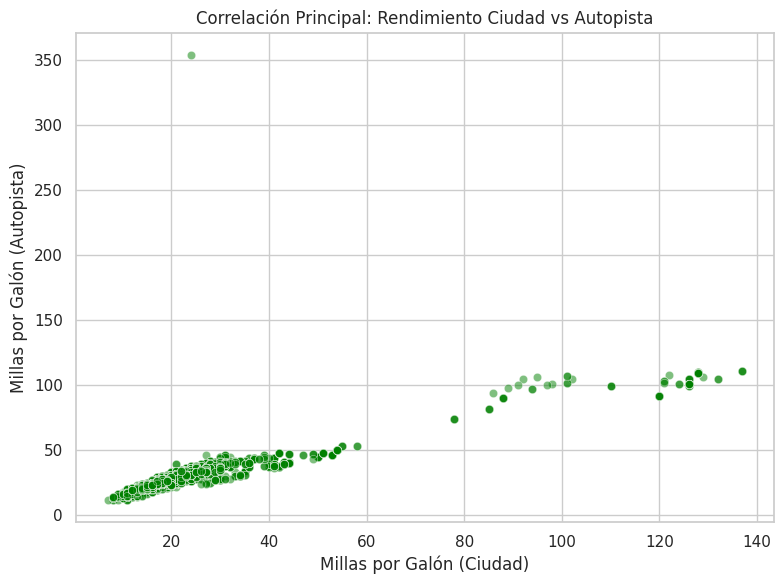

In [71]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x='city mpg', y='highway MPG', data=df, color='green', alpha=0.5)
plt.title('Correlación Principal: Rendimiento Ciudad vs Autopista')
plt.xlabel('Millas por Galón (Ciudad)')
plt.ylabel('Millas por Galón (Autopista)')

plt.tight_layout()
plt.show()

Al graficar este par de variables con un diagrama de dispersión, observamos una relación lineal positiva casi perfecta. La gran mayoría de los carros de que utilizan combustible tradicional se agrupan en la zona inferior izquierda entre las 10 y 40 MPG. Sin embargo, la gráfica también expone visualmente a los valores anomalos extremos que se extienden hacia la parte superior derecha \. Estos puntos aislados que siguen la misma tendencia ascendente corresponden a los vehículos 100% eléctricos.

Al detallar mas a profundidad este grafico, se detecto un valor inusual e inconsistente, en este caso es un carro que registra un rendimiento normal en ciudad con un rendimiento demasiado bueno que resulta imposible en carretera.

Para esto, vamos a verificar que tipo de carro es el que genera ese punto disperso.

In [72]:
display(df.nlargest(1, 'highway MPG'))

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
1119,Audi,A6,2017,premium unleaded (recommended),252.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Luxury,Midsize,Sedan,354,24,3105,51600


Al consultar el dataset, descubrimos que esta observación pertenece a un Audi A6 del 2017. Esto es un error de digitación en la recolección de datos, probablemente un 34 o 35 tipeado erróneamente como 354. Identificar este tipo de anomalías es importante, porque nos indica qué registros específicos deberán ser corregidos o eliminados en el preprocesamiento.